In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)


In [ ]:
import os
os.listdir("/content/drive/MyDrive/")


['Colab Notebooks',
 'LeafPulse',
 'New Plant Diseases Dataset(Augmented)',
 'ColabNotebooks',
 'Late_Blight_tomatoes_featured.jpg',
 '.ipynb_checkpoints',
 'Major Project']

In [ ]:
import os
os.listdir("/content/drive/MyDrive/Major Project/")


['Data', 'NoteBooks', 'Models']

In [ ]:
data_path = "/content/drive/MyDrive/Major Project/Data/smart_manufacturing_data.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (100000, 13)


,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


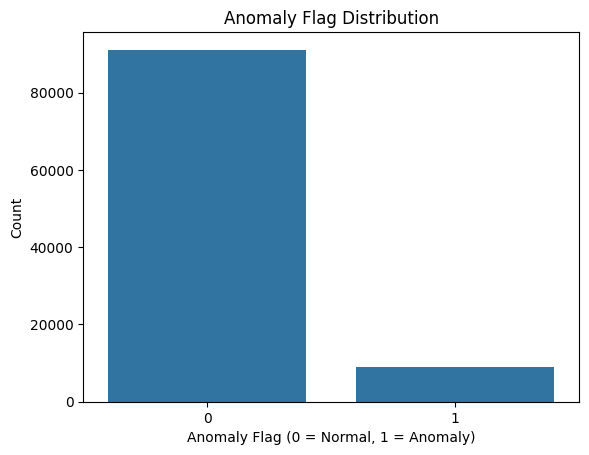

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='anomaly_flag', data=df)
plt.title("Anomaly Flag Distribution")
plt.xlabel("Anomaly Flag (0 = Normal, 1 = Anomaly)")
plt.ylabel("Count")
plt.show()


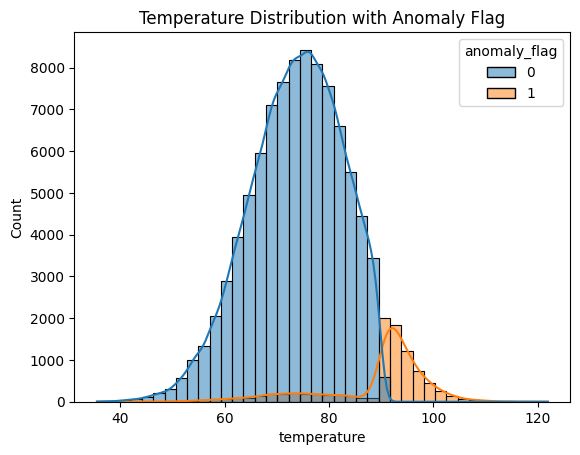

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=df,
    x='temperature',
    hue='anomaly_flag',
    bins=40,
    kde=True
)
plt.title("Temperature Distribution with Anomaly Flag")
plt.show()


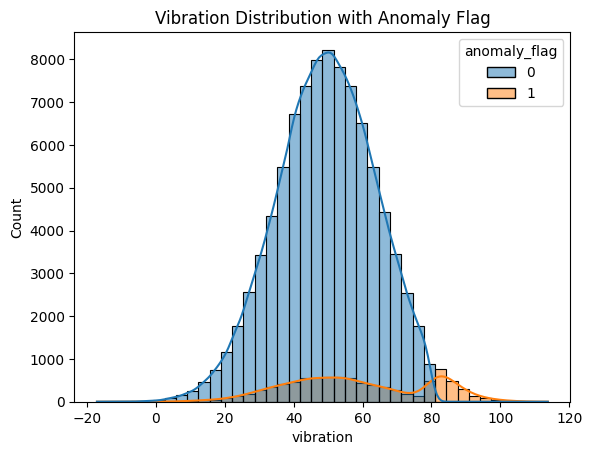

In [ ]:
sns.histplot(
    data=df,
    x='vibration',
    hue='anomaly_flag',
    bins=40,
    kde=True
)
plt.title("Vibration Distribution with Anomaly Flag")
plt.show()


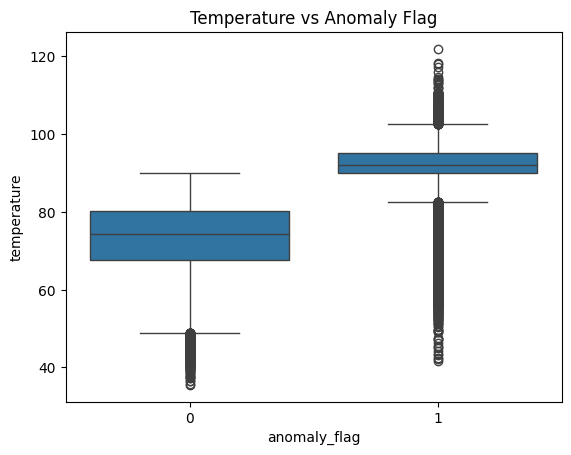

In [ ]:
sns.boxplot(x='anomaly_flag', y='temperature', data=df)
plt.title("Temperature vs Anomaly Flag")
plt.show()


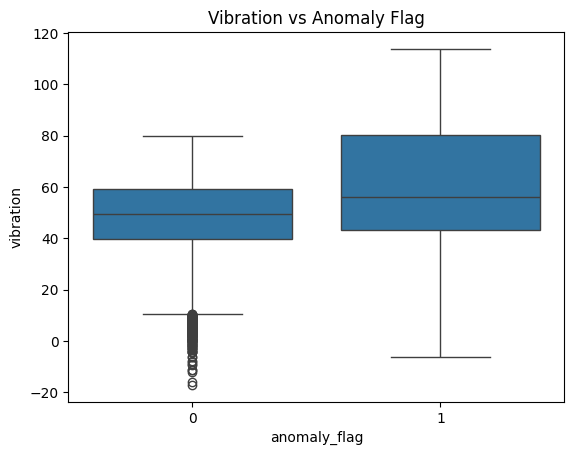

In [ ]:
sns.boxplot(x='anomaly_flag', y='vibration', data=df)
plt.title("Vibration vs Anomaly Flag")
plt.show()


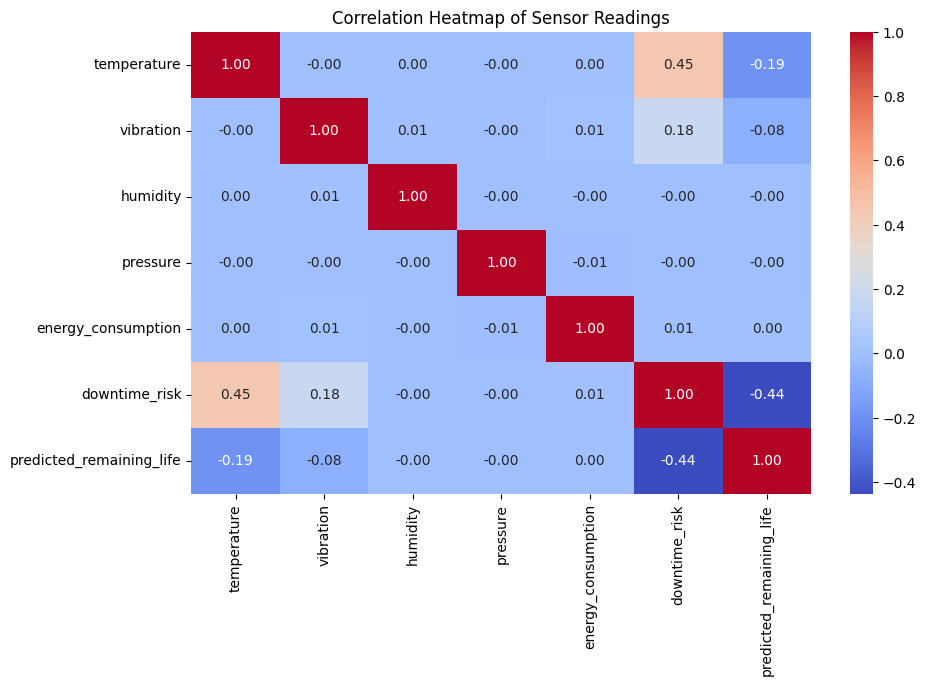

In [ ]:
numerical_cols = [
    'temperature',
    'vibration',
    'humidity',
    'pressure',
    'energy_consumption',
    'downtime_risk',
    'predicted_remaining_life'
]

corr = df[numerical_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Sensor Readings")
plt.show()


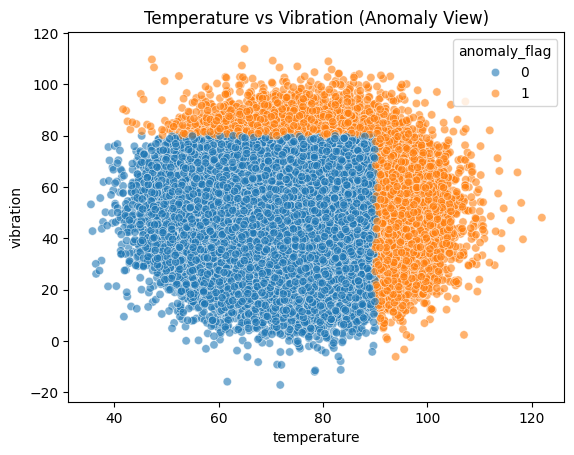

In [ ]:
sns.scatterplot(
    data=df,
    x='temperature',
    y='vibration',
    hue='anomaly_flag',
    alpha=0.6
)
plt.title("Temperature vs Vibration (Anomaly View)")
plt.show()


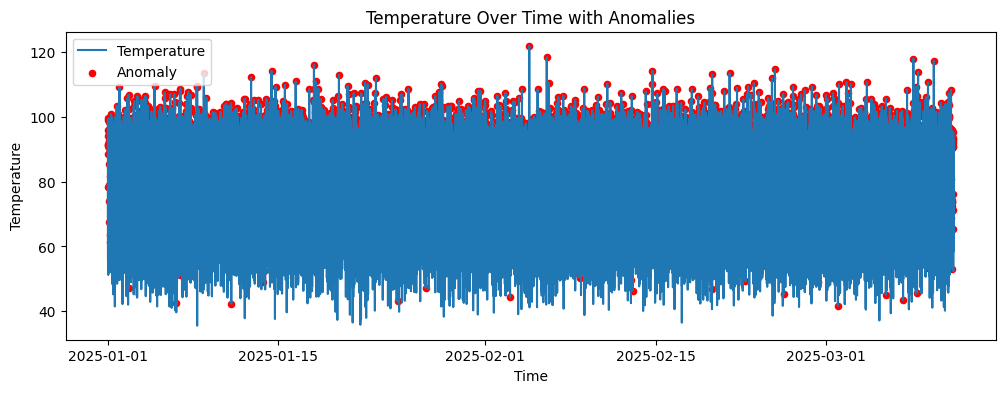

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df_sorted = df.sort_values('timestamp')

plt.figure(figsize=(12, 4))
plt.plot(df_sorted['timestamp'], df_sorted['temperature'], label='Temperature')

anomalies = df_sorted[df_sorted['anomaly_flag'] == 1]
plt.scatter(
    anomalies['timestamp'],
    anomalies['temperature'],
    color='red',
    label='Anomaly',
    s=20
)

plt.title("Temperature Over Time with Anomalies")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()


In [ ]:
num_features = [
    'temperature',
    'vibration',
    'humidity',
    'pressure',
    'energy_consumption'
]

cat_features = [
    'machine_status',
    'machine_id'
]

X = df[num_features + cat_features]
y = df['anomaly_flag']  # evaluation only


In [ ]:
X_train = X[y == 0]   # normal data only
X_test = X           # full data for evaluation


In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


model

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import numpy as np
import joblib
import os

# -----------------------------
# 1. Define model save path
# -----------------------------
model_dir = "/content/drive/MyDrive/Major Project/Models"
model_path = os.path.join(model_dir, "isolation_forest.pkl")
os.makedirs(model_dir, exist_ok=True)

# -----------------------------
# 2. Train Isolation Forest on NORMAL only
# -----------------------------
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.09,   # Set to your known anomaly ratio
    random_state=42
)

iso_forest.fit(X_train_processed)

# -----------------------------
# 3. Predict on full dataset
# -----------------------------
y_pred = iso_forest.predict(X_test_processed)

# Convert IF output to dataset format
# +1 -> normal (0), -1 -> anomaly (1)
y_pred = np.where(y_pred == -1, 1, 0)

# -----------------------------
# 4. Evaluate performance
# -----------------------------
print("Accuracy:", accuracy_score(y, y_pred))
print("\nClassification Report:")
print(classification_report(y, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred))
print("\nROC AUC Score:")
print(roc_auc_score(y, iso_forest.decision_function(X_test_processed)))

# -----------------------------
# 5. Save best model only
# -----------------------------
if not os.path.exists(model_path):
    joblib.dump(iso_forest, model_path)
    print("\nModel saved (first run).")

else:
    saved_model = joblib.load(model_path)
    saved_pred = saved_model.predict(X_test_processed)
    saved_pred = np.where(saved_pred == -1, 1, 0)

    saved_accuracy = accuracy_score(y, saved_pred)

    if accuracy_score(y, y_pred) > saved_accuracy:
        joblib.dump(iso_forest, model_path)
        print("\nNew model performed better. Model updated.")
    else:
        print("\nExisting model performs better. Keeping saved model.")


Accuracy: 0.84301

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91     91084
           1       0.15      0.16      0.15      8916

    accuracy                           0.84    100000
   macro avg       0.53      0.53      0.53    100000
weighted avg       0.85      0.84      0.85    100000


Confusion Matrix:
[[82886  8198]
 [ 7501  1415]]

ROC AUC Score:
0.36481836514961546

Existing model performs better. Keeping saved model.


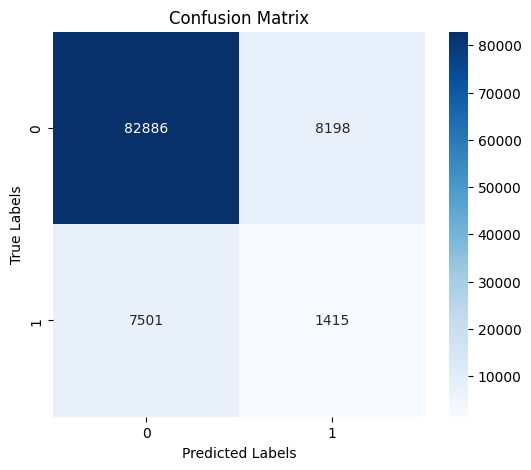

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

report = classification_report(y, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df


,precision,recall,f1-score,support
0,0.917012,0.909995,0.913490,91084.00000
1,0.147197,0.158703,0.152734,8916.00000
accuracy,0.843010,0.843010,0.843010,0.84301
macro avg,0.532104,0.534349,0.533112,100000.00000
weighted avg,0.848376,0.843010,0.845661,100000.00000


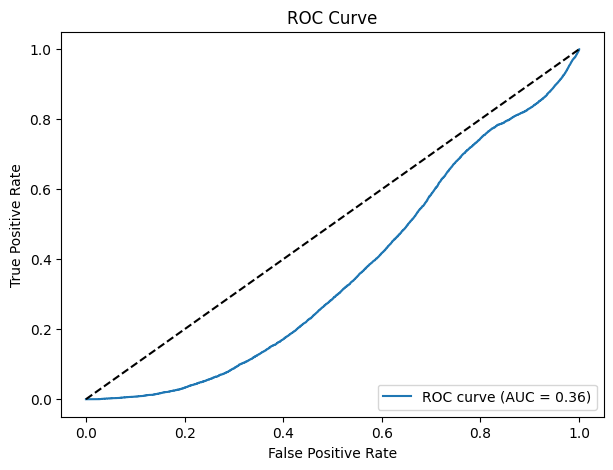

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_scores = iso_forest.decision_function(X_test_processed)

fpr, tpr, thresholds = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()


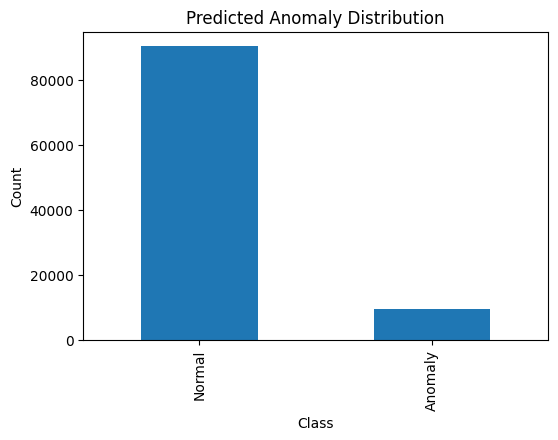

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

dist = pd.Series(y_pred).value_counts().sort_index()
dist.index = ['Normal', 'Anomaly']

plt.figure(figsize=(6,4))
dist.plot(kind='bar')
plt.title("Predicted Anomaly Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

# Scale
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled  = scaler.transform(X_test_processed)

# Convert sparse to dense
X_train_dense = X_train_scaled.toarray()
X_test_dense  = X_test_scaled.toarray()

# Build Autoencoder
input_dim = X_train_dense.shape[1]

input_layer = Input(shape=(input_dim,))

encoded = Dense(64, activation="relu")(input_layer)
encoded = Dense(32, activation="relu")(encoded)
encoded = Dense(16, activation="relu")(encoded)

decoded = Dense(32, activation="relu")(encoded)
decoded = Dense(64, activation="relu")(decoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

# Train
autoencoder.fit(
    X_train_dense,
    X_train_dense,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    shuffle=True
)


Epoch 1/50
321/321 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.8162 - val_loss: 0.2204
Epoch 2/50
321/321 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1754 - val_loss: 0.1176
Epoch 3/50
321/321 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1138 - val_loss: 0.1086
Epoch 4/50
321/321 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1080 - val_loss: 0.1055
Epoch 5/50
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1037 - val_loss: 0.0970
Epoch 6/50
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0933 - val_loss: 0.0846
Epoch 7/50
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0824 - val_loss: 0.0786
Epoch 8/50
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0777 - val_loss: 0.0762
Epoch 9/50
321/321 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0755 - val_loss: 0.0749
Epoch 10/50
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0745 - val_loss: 0.0743
Epoch 11/50
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0738 - val_loss: 0.0726
Epoch 12/50
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/st

In [ ]:
import numpy as np

# Predict (reconstruct) on test data
X_test_pred = autoencoder.predict(X_test_dense)

# Calculate reconstruction error
mse = np.mean(np.power(X_test_dense - X_test_pred, 2), axis=1)


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step


In [ ]:
threshold = np.percentile(mse, 95)
print("Threshold:", threshold)


Threshold: 0.10649471616044323


In [ ]:
y_pred = np.where(mse > threshold, 1, 0)


In [ ]:
print("Total anomalies predicted:", np.sum(y_pred))
print("Total normal predicted:", len(y_pred) - np.sum(y_pred))


Total anomalies predicted: 5000
Total normal predicted: 95000


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y, y_pred))


              precision    recall  f1-score   support

           0       0.92      0.96      0.94     91084
           1       0.32      0.18      0.23      8916

    accuracy                           0.89    100000
   macro avg       0.62      0.57      0.58    100000
weighted avg       0.87      0.89      0.88    100000

Confusion Matrix:
 [[87659  3425]
 [ 7341  1575]]


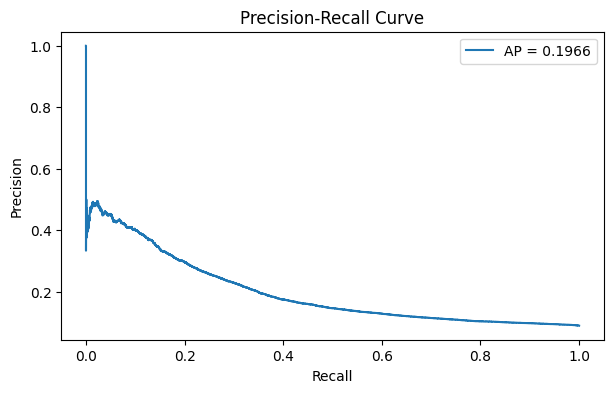

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y, mse)
avg_precision = average_precision_score(y, mse)

plt.figure(figsize=(7,4))
plt.plot(recall, precision, label=f"AP = {avg_precision:.4f}")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


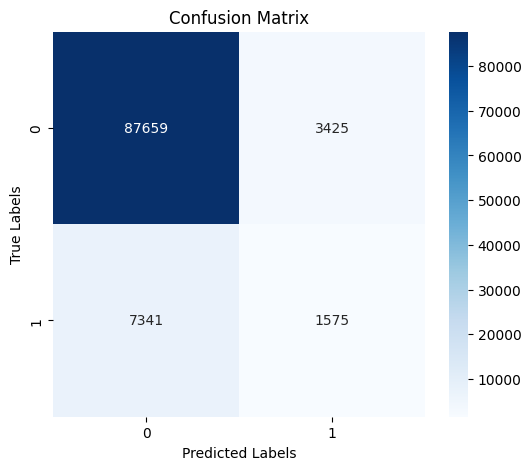

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Updated confusion matrix values
conf_matrix = np.array([[87659, 3425],
                        [7341, 1575]])

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()
